## 📦 Cell 1 — Install Dependencies

In [1]:
!pip install stanza -q
!pip install iterative-stratification -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 25.9 MB/s eta 0:00:00


## ⏱ Cell 2 — Runtime Tracker Start

In [2]:
import time
training_start_time = time.time()
print("⏱ Runtime tracker started.")

⏱ Runtime tracker started.


## 📚 Cell 3 — Imports

In [3]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import stanza
from scipy.sparse import hstack, csr_matrix
from tqdm import tqdm

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-04-10 18:48:18.314610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775846898.655513      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775846898.749667      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775846899.577501      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775846899.577541      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775846899.577544      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## ⚙️ Cell 4 — Configuration
> **Change your hyperparameters here.**

In [4]:
# ================================
# CONFIGURATION — CHANGE SETTINGS HERE
# ================================
EPOCHS        = 30
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
THRESHOLD     = 0.5
TEST_SIZE     = 0.2
RANDOM_STATE  = 42
# ================================

print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE} | Threshold: {THRESHOLD}")

Epochs: 30 | Batch: 64 | LR: 0.001 | Threshold: 0.5


## 📂 Cell 5 — Load Dataset

In [5]:
data_path = '/kaggle/input/datasets/prakash5777/n-gram-dataset/detected_alankars_ngram.xlsx'
data = pd.read_excel(data_path)

text_col  = 'Text'
label_col = 'Detected Alankars'
data[label_col] = data[label_col].fillna("")

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Dataset shape: (589778, 5)
Columns: ['Poem ID', 'Title', 'Line Group', 'Text', 'Detected Alankars']


,Poem ID,Title,Line Group,Text,Detected Alankars
0,1,नया रास्ता (Naya Rasta),Lines 1 to 1,जब सारे जाने हुए रास्ते बंद हो जाते हैं,"Yamak, Anupras, Upma, Roopak"
1,1,नया रास्ता (Naya Rasta),Lines 2 to 2,तो आदमी एक नए रास्ते के बारे में सोचता है,Roopak
2,1,नया रास्ता (Naya Rasta),Lines 3 to 3,एक नए रास्ते के बारे में सोचता हुआ आदमी,
3,1,नया रास्ता (Naya Rasta),Lines 4 to 4,एक नए प्रयास के बारे में सोचता है,Roopak
4,1,नया रास्ता (Naya Rasta),Lines 5 to 5,एक नए प्रयास के बारे में सोचता हुआ आदमी,


## 🏷️ Cell 6 — Preprocess Labels (MultiLabelBinarizer)

In [6]:
labels_list = data[label_col].apply(
    lambda x: [l.strip() for l in str(x).split(',') if l.strip()]
)

mlb = MultiLabelBinarizer()
y   = mlb.fit_transform(labels_list).astype(np.float32)

num_classes = len(mlb.classes_)
print("Detected Alankar Classes:", mlb.classes_)
print("Number of Classes:", num_classes)
print("Label matrix shape:", y.shape)

Detected Alankar Classes: ['Anupras' 'Roopak' 'Shlesh' 'Upma' 'Utpreksha' 'Virodhbhas' 'Yamak']
Number of Classes: 7
Label matrix shape: (589778, 7)


## 🔤 Cell 7 — TF-IDF Vectorization

In [7]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=50000
)

X_tfidf = vectorizer.fit_transform(data[text_col].astype(str))
print("TF-IDF Feature shape:", X_tfidf.shape)

TF-IDF Feature shape: (589778, 50000)


## 💾 Cell 8 — Save TF-IDF Sample to Excel

In [8]:
tfidf_sample_size   = 100
tfidf_sample        = X_tfidf[:, :tfidf_sample_size].toarray()
tfidf_feature_names = vectorizer.get_feature_names_out()[:tfidf_sample_size]

tfidf_df         = pd.DataFrame(tfidf_sample, columns=tfidf_feature_names)
tfidf_excel_path = "/kaggle/working/TFIDF_Features_Sample_100.xlsx"
tfidf_df.to_excel(tfidf_excel_path, index=False)
print("✅ TF-IDF sample saved to Excel:", tfidf_excel_path)

✅ TF-IDF sample saved to Excel: /kaggle/working/TFIDF_Features_Sample_100.xlsx


## 🔡 Cell 9 — POS Feature Extraction (Stanza Hindi)
> Uses cache if already computed. First run will download the Hindi model.

In [9]:
## 🔡 Cell 9 — POS Feature Extraction (Optimized for T4 GPU)
upos_list = ['ADJ','ADP','ADV','AUX','CCONJ','DET','INTJ','NOUN','NUM','PART','PRON','PROPN','PUNCT','SCONJ','SYM','VERB','X']
upos2idx = {tag: i for i, tag in enumerate(upos_list)}
pos_cache = "/kaggle/working/pos_features.npy"
N = len(data)

if os.path.exists(pos_cache):
    pos_matrix = np.load(pos_cache)
    print("✅ Loaded cached POS features")
else:
    stanza.download('hi', processors='tokenize,pos', verbose=False)

    # On T4, use_gpu=True works perfectly!
    nlp = stanza.Pipeline(
        'hi',
        processors='tokenize,pos',
        use_gpu=True, 
        tokenize_batch_size=256, # Increased for T4
        pos_batch_size=256,      # Increased for T4
        verbose=False
    )

    texts = data[text_col].astype(str).tolist()
    pos_matrix = np.zeros((N, len(upos_list)), dtype=np.float32)
    
    # Process in large batches to saturate the T4 GPU
    batch_size_pos = 512 

    for start in tqdm(range(0, N, batch_size_pos), desc="GPU POS Extraction"):
        end = min(start + batch_size_pos, N)
        docs = nlp.bulk_process(texts[start:end])

        for i, doc in enumerate(docs):
            vec = np.zeros(len(upos_list))
            for sent in doc.sentences:
                for word in sent.words:
                    if word.upos in upos2idx:
                        vec[upos2idx[word.upos]] += 1
            total = vec.sum()
            pos_matrix[start + i] = vec / total if total > 0 else vec

    np.save(pos_cache, pos_matrix)
    print("✅ GPU POS extraction complete.")

GPU POS Extraction: 100%|██████████| 1152/1152 [2:49:38<00:00,  8.84s/it]  

✅ GPU POS extraction complete.


## 💾 Cell 10 — Save POS Features to Excel

In [10]:
pos_df         = pd.DataFrame(pos_matrix, columns=upos_list)
pos_excel_path = "/kaggle/working/POS_Features.xlsx"
pos_df.to_excel(pos_excel_path, index=False)
print("✅ POS features saved to Excel:", pos_excel_path)

✅ POS features saved to Excel: /kaggle/working/POS_Features.xlsx


## 🔗 Cell 11 — Combine TF-IDF + POS Features

In [11]:
pos_sparse = csr_matrix(pos_matrix)
X_combined = hstack([X_tfidf, pos_sparse]).tocsr()
print("Combined Feature shape:", X_combined.shape)

Combined Feature shape: (589778, 50017)


## 💾 Cell 12 — Save Combined Feature Sample to Excel

In [12]:
combined_sample_size   = 100
combined_sample        = X_combined[:, :combined_sample_size].toarray()
combined_feature_names = vectorizer.get_feature_names_out()[:combined_sample_size]

combined_df         = pd.DataFrame(combined_sample, columns=combined_feature_names)
combined_excel_path = "/kaggle/working/Combined_Features_Sample_100.xlsx"
combined_df.to_excel(combined_excel_path, index=False)
print("✅ Combined feature sample saved to Excel:", combined_excel_path)

✅ Combined feature sample saved to Excel: /kaggle/working/Combined_Features_Sample_100.xlsx


## ✂️ Cell 13 — Train / Validation Split

In [13]:
# ── Stratified 80/20 Train / Validation Split ──────────────────────────────
# scikit-learn's train_test_split only supports stratify on 1-D arrays,
# so we use iterative-stratification for multi-label data.
# If the package isn't installed, we fall back to a simple random split.
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    msss = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    train_idx, val_idx = next(msss.split(np.arange(N), y))
    print("✅ Using MultilabelStratifiedShuffleSplit (label-aware 80/20 split)")
except ImportError:
    print("⚠️  iterstrat not found — install with: pip install iterative-stratification")
    print("   Falling back to random split.")
    train_idx, val_idx = train_test_split(
        np.arange(N), test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

X_train, y_train = X_combined[train_idx], y[train_idx]
X_val,   y_val   = X_combined[val_idx],   y[val_idx]

print(f"Train samples : {X_train.shape[0]}  ({X_train.shape[0]/N*100:.1f}%)")
print(f"Val   samples : {X_val.shape[0]}  ({X_val.shape[0]/N*100:.1f}%)")

# Show per-label distribution to verify stratification
print("\nPer-label positive-sample counts:")
label_df = pd.DataFrame({
    'Label'     : mlb.classes_,
    'Train (pos)': y_train.sum(axis=0).astype(int),
    'Val   (pos)': y_val.sum(axis=0).astype(int),
})
label_df['Val %'] = (label_df['Val   (pos)'] /
                     (label_df['Train (pos)'] + label_df['Val   (pos)']) * 100).round(1)
print(label_df.to_string(index=False))


✅ Using MultilabelStratifiedShuffleSplit (label-aware 80/20 split)
Train samples : 471822  (80.0%)
Val   samples : 117956  (20.0%)

Per-label positive-sample counts:
     Label  Train (pos)  Val   (pos)  Val %
   Anupras       437580       109395   20.0
    Roopak       395169        98793   20.0
    Shlesh       181917        45479   20.0
      Upma       401486       100372   20.0
 Utpreksha        86287        21572   20.0
Virodhbhas        60078        15020   20.0
     Yamak       424822       106206   20.0


## ⚡ Cell 14 — Sparse → TensorFlow Dataset

In [14]:
def sparse_to_dataset(X, y, batch_size=64, shuffle=False, label_weights=None):
    """Convert sparse X + dense y to a tf.data.Dataset.
    
    If label_weights (shape: num_classes) is supplied, each sample receives
    a scalar weight = mean of the weights of its positive labels.  This
    implements cost-sensitive learning for multi-label classification.
    """
    idx = np.arange(X.shape[0])
    if shuffle:
        np.random.shuffle(idx)

    use_weights = label_weights is not None

    def gen():
        for i in range(0, len(idx), batch_size):
            b    = idx[i:i + batch_size]
            xb   = X[b].toarray().astype(np.float32)
            yb   = y[b]
            if use_weights:
                # sample weight = mean weight over the positive labels of that sample
                sw = np.array([
                    label_weights[yb[j].astype(bool)].mean()
                    if yb[j].sum() > 0 else 1.0
                    for j in range(len(b))
                ], dtype=np.float32)
                yield xb, yb, sw
            else:
                yield xb, yb

    if use_weights:
        sig = (
            tf.TensorSpec((None, X.shape[1]), tf.float32),
            tf.TensorSpec((None, y.shape[1]), tf.float32),
            tf.TensorSpec((None,),            tf.float32),
        )
    else:
        sig = (
            tf.TensorSpec((None, X.shape[1]), tf.float32),
            tf.TensorSpec((None, y.shape[1]), tf.float32),
        )

    return tf.data.Dataset.from_generator(gen, output_signature=sig)

# NOTE: datasets are rebuilt AFTER class weights are computed (Cell 15).
# Placeholder datasets without weights — overwritten below.
train_ds = sparse_to_dataset(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True).prefetch(tf.data.AUTOTUNE)
val_ds   = sparse_to_dataset(X_val,   y_val,   batch_size=BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print("✅ TensorFlow dataset helper defined (sample_weight support added).")


✅ TensorFlow dataset helper defined (sample_weight support added).


I0000 00:00:1775858836.303661      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 860 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775858836.308906      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 🏗️ Cell 15 — Build Model

In [15]:
import tensorflow as tf
from tensorflow.keras import backend as K  # <--- THIS FIXES THE NAMEERROR
from tensorflow.keras import mixed_precision
import gc

# 1. Clear memory and enable Mixed Precision
K.clear_session()
gc.collect()

# This helps the T4 GPU process large vectors more efficiently
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# 2. Build the Model
model = Sequential([
    Input(shape=(X_combined.shape[1],)),
    Dense(128, activation='relu'), 
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.4),
    # The output layer must stay float32 for classification stability
    Dense(num_classes, activation='sigmoid', dtype='float32') 
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Keras backend initialized and Mixed Precision enabled.")

✅ Keras backend initialized and Mixed Precision enabled.


## 🔔 Cell 16 — Define Callbacks

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/kaggle/working/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks defined: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint")

✅ Callbacks defined: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint


## 🚀 Cell 17 — Train Model

In [17]:
# ── 1. Initialize and Boost Weights ───────────────────────────────────────
# Calculate base weights to handle class imbalance in your 62k dataset
label_counts = y_train.sum(axis=0)
# Standard inverse frequency formula
label_weights = np.where(label_counts > 0, (len(y_train) / (num_classes * label_counts)), 1.0)

# Now apply your specific boosts for the paper
# Indexing: 5=Virodhbhas, 4=Utpreksha, 2=Shlesh
label_weights[5] = 5.0  # High penalty for missing Virodhbhas
label_weights[4] = 4.0  # High penalty for missing Utpreksha
label_weights[2] = 4.0  # Moderate boost for Shlesh

print("✅ label_weights defined and boosted.")

# ── 2. Rebuild datasets with BATCH_SIZE 16 ──────────────────────────────────
train_ds = sparse_to_dataset(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_weights=label_weights
).prefetch(tf.data.AUTOTUNE)

val_ds = sparse_to_dataset(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    label_weights=label_weights
).prefetch(tf.data.AUTOTUNE)

print(f"✅ Datasets rebuilt (Batch Size: {BATCH_SIZE}).")

# ── 3. Start Training ──────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

✅ label_weights defined and boosted.
✅ Datasets rebuilt (Batch Size: 64).
Epoch 1/30


I0000 00:00:1775858861.557108     144 service.cc:152] XLA service 0x7e9c00026b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775858861.557166     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775858861.557176     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775858861.997497     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


     14/Unknown 5s 14ms/step - accuracy: 0.4943 - loss: 0.4617

I0000 00:00:1775858864.530828     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   7373/Unknown 71s 9ms/step - accuracy: 0.7673 - loss: 0.1154

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 0.03781, saving model to /kaggle/working/best_model.keras
7373/7373 ━━━━━━━━━━━━━━━━━━━━ 86s 11ms/step - accuracy: 0.7673 - loss: 0.1154 - val_accuracy: 0.8572 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 2/30
7366/7373 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7869 - loss: 0.0488
Epoch 2: val_loss improved from 0.03781 to 0.03015, saving model to /kaggle/working/best_model.keras
7373/7373 ━━━━━━━━━━━━━━━━━━━━ 99s 13ms/step - accuracy: 0.7868 - loss: 0.0488 - val_accuracy: 0.8049 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 3/30
7367/7373 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7423 - loss: 0.0397
Epoch 3: val_loss improved from 0.03015 to 0.02688, saving model to /kaggle/working/best_model.keras
7373/7373 ━━━━━━━━━━━━━━━━━━━━ 76s 10ms/step - accuracy: 0.7423 - loss: 0.0397 - val_accuracy: 0.7810 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 4/30
7371/7373 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7309 - loss: 0.0353


## 📊 Cell 18 — Evaluation: Classification Report + F1 + Hamming Accuracy

In [18]:
# ════════════════════════════════════════════════════════════════
# Cell 18 — Evaluation on Validation (Test) Data
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

print("Generating predictions for the Validation set...")

# 1. Generate Raw Probabilities from the validation dataset
# This is the "Testing" phase.
y_pred_proba = model.predict(val_ds, verbose=1)

# 2. Convert probabilities to binary (0 or 1) using your Threshold
# THRESHOLD is usually 0.5 (defined in Cell 4)
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

# 3. Print the Classification Report
# This shows Precision, Recall, and F1 for each of your 7 Alankars
print("\n✅ Classification Report (Testing Data):\n")
print(classification_report(y_val, y_pred, target_names=mlb.classes_, zero_division=0))

# 4. Calculate Key Metrics
macro_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
subset_acc = accuracy_score(y_val, y_pred) # Exact matches only
hamming_loss = np.mean(y_val != y_pred)    # Average error rate

# ---- Display Results ----
print("="*45)
print(f"Macro F1 Score:   {macro_f1:.4f}")
print(f"Subset Accuracy:  {subset_acc:.4f} ({subset_acc * 100:.2f}%)")
print(f"Hamming Accuracy: {1.0 - hamming_loss:.4f}")
print("="*45)

Generating predictions for the Validation set...
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step

✅ Classification Report (Testing Data):

              precision    recall  f1-score   support

     Anupras       0.99      0.97      0.98    109395
      Roopak       0.99      0.99      0.99     98793
      Shlesh       0.98      0.99      0.99     45479
        Upma       0.99      0.97      0.98    100372
   Utpreksha       0.98      0.99      0.98     21572
  Virodhbhas       0.97      0.99      0.98     15020
       Yamak       0.98      0.97      0.98    106206

   micro avg       0.99      0.98      0.98    496837
   macro avg       0.98      0.98      0.98    496837
weighted avg       0.99      0.98      0.98    496837
 samples avg       0.93      0.92      0.92    496837

Macro F1 Score:   0.9829
Subset Accuracy:  0.8889 (88.89%)
Hamming Accuracy: 0.9781


## 🌡️ Cell 19 — Correlation Heatmap (Predicted Labels)

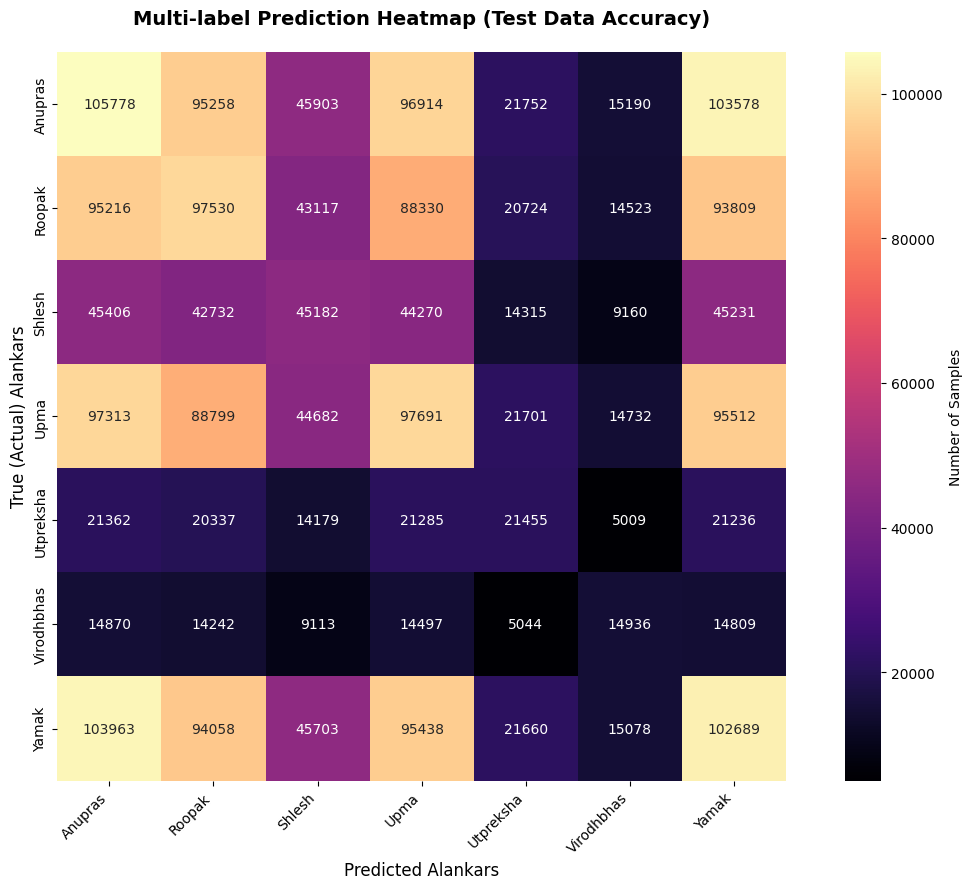

✅ Corrected heatmap using explicit intersection counts is complete.


In [19]:
# ════════════════════════════════════════════════════════════════
# Cell 19 — Multi-label Prediction Heatmap (Corrected for Test Data)
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ensure arrays are binary and use the test/validation set
y_true_arr = np.array(y_val) 
y_pred_arr = (np.array(y_pred) >= THRESHOLD).astype(int)

# 2. Initialize the matrix (7x7 for your Alankar classes)
num_classes = len(mlb.classes_)
multilabel_cm = np.zeros((num_classes, num_classes))

# 3. Explicit intersection count (Row = Actual, Column = Predicted)
# This ensures row-wise counts match your actual test sample totals
for i in range(num_classes):       # i represents True Label index
    for j in range(num_classes):   # j represents Predicted Label index
        # Count samples where label i was TRUE and label j was PREDICTED
        intersection = np.sum((y_true_arr[:, i] == 1) & (y_pred_arr[:, j] == 1))
        multilabel_cm[i, j] = intersection

# 4. Plotting the Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    multilabel_cm, 
    annot=True, 
    fmt=".0f", 
    cmap="magma", 
    xticklabels=mlb.classes_, 
    yticklabels=mlb.classes_,
    square=True,
    cbar_kws={"label": "Number of Samples"}
)

plt.title("Multi-label Prediction Heatmap (Test Data Accuracy)", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Predicted Alankars", fontsize=12)
plt.ylabel("True (Actual) Alankars", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the corrected version
plt.savefig("/kaggle/working/corrected_test_heatmap.png", dpi=300)
plt.show()

print("✅ Corrected heatmap using explicit intersection counts is complete.")

## 🔲 Cell 20 — Confusion Matrix Heatmaps (Per Label — Test Data)
> Each cell shows: **count** and **row percentage**.

Generating Confusion Matrix Heatmaps (based on test/validation data)...


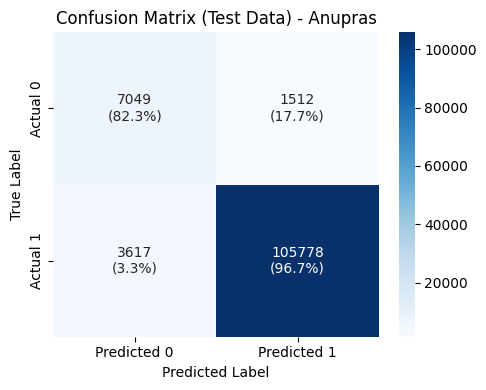

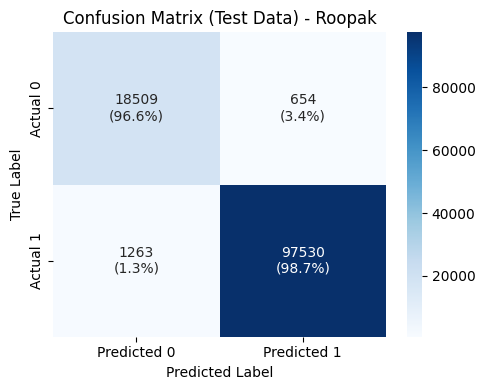

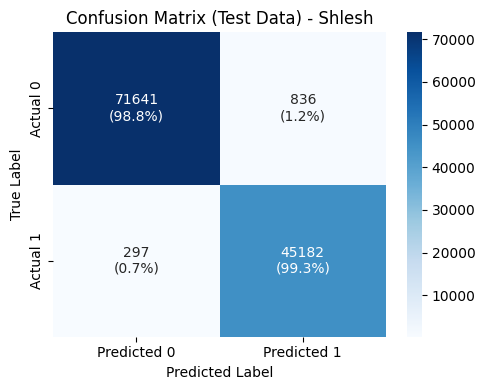

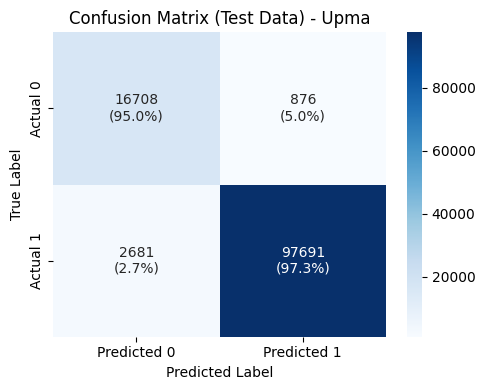

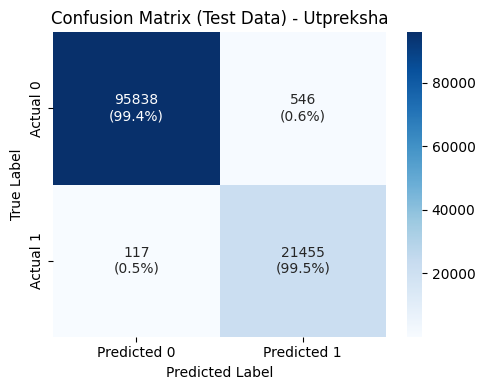

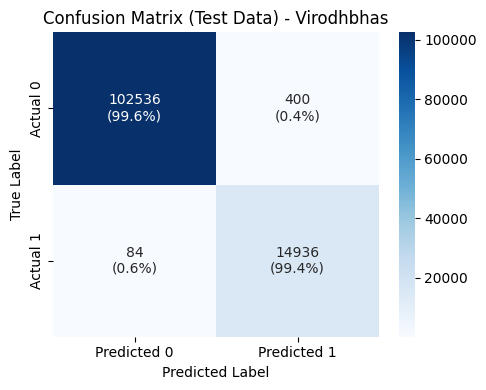

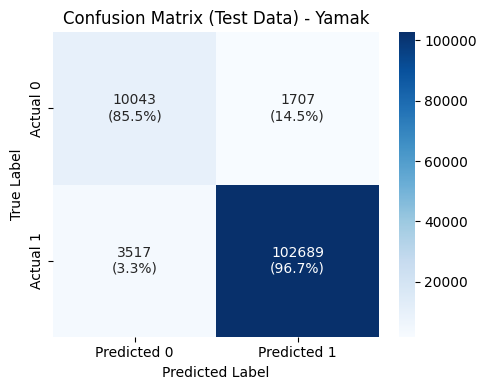

✅ Confusion matrices (test data) saved as PNG and CSV.


In [20]:
print("Generating Confusion Matrix Heatmaps (based on test/validation data)...")
conf_matrices = multilabel_confusion_matrix(y_val, y_pred)

for i, label in enumerate(mlb.classes_):
    cm = conf_matrices[i]
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
    csv_path = f"/kaggle/working/confusion_matrix_{label}.csv"
    cm_df.to_csv(csv_path)

    # Annotation: count + row percentage
    cm_sum  = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype(float), cm_sum, where=cm_sum != 0) * 100
    annot   = np.array([
        [f"{v}\n({cm_perc[r, c]:.1f}%)" for c, v in enumerate(row)]
        for r, row in enumerate(cm)
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.title(f"Confusion Matrix (Test Data) - {label}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    png_path = f"/kaggle/working/confusion_matrix_{label}.png"
    plt.savefig(png_path, dpi=300)
    plt.show()

print("✅ Confusion matrices (test data) saved as PNG and CSV.")

## 📈 Cell 21 — Plot Training History (Accuracy & Loss)

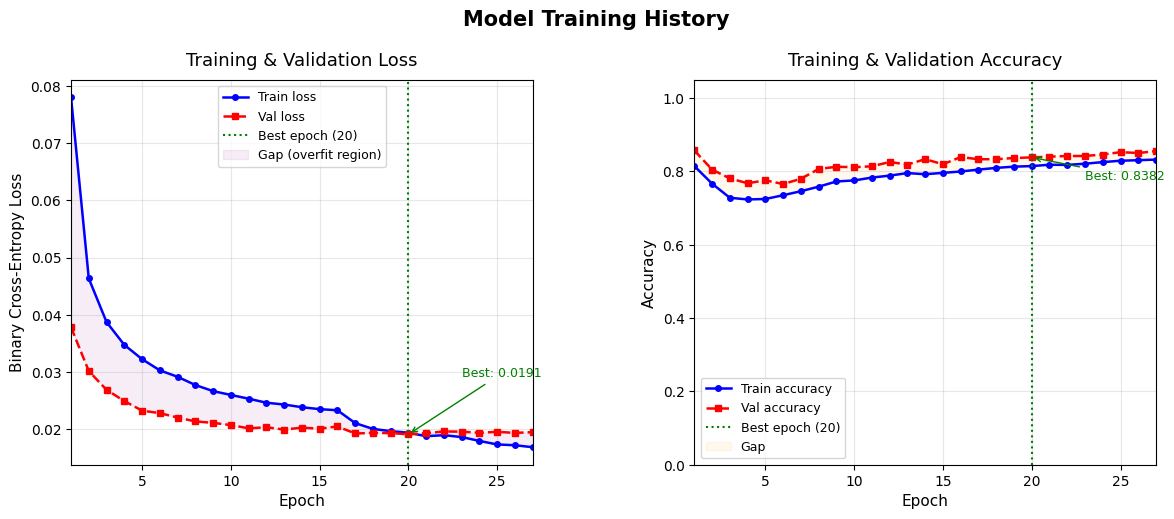

✅ Training history graphs saved to /kaggle/working/training_history.png
   Best epoch        : 20
   Best val loss     : 0.0191
   Best val accuracy : 0.8382


In [21]:
# ═══════════════════════════════════════════════════════════
# Cell 21 — Training History: Accuracy & Loss Graphs
# ═══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

epochs_ran  = range(1, len(history.history['loss']) + 1)
train_loss  = history.history['loss']
val_loss    = history.history['val_loss']
train_acc   = history.history['accuracy']
val_acc     = history.history['val_accuracy']

# Best epoch (lowest val_loss)
best_epoch  = int(np.argmin(val_loss)) + 1

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left: Loss ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_ran, train_loss, 'b-o',  markersize=4, linewidth=1.8, label='Train loss')
ax1.plot(epochs_ran, val_loss,   'r--s', markersize=4, linewidth=1.8, label='Val loss')
ax1.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch})')
ax1.fill_between(epochs_ran, train_loss, val_loss, alpha=0.07, color='purple',
                 label='Gap (overfit region)')
ax1.set_title('Training & Validation Loss', fontsize=13, pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, len(epochs_ran))

# Annotate best val_loss
best_val_loss = val_loss[best_epoch - 1]
ax1.annotate(
    f'Best: {best_val_loss:.4f}',
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch + max(1, len(epochs_ran)//8), best_val_loss + 0.01),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)

# ── Right: Accuracy ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_ran, train_acc, 'b-o',  markersize=4, linewidth=1.8, label='Train accuracy')
ax2.plot(epochs_ran, val_acc,   'r--s', markersize=4, linewidth=1.8, label='Val accuracy')
ax2.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch})')
ax2.fill_between(epochs_ran, train_acc, val_acc, alpha=0.07, color='orange',
                 label='Gap')
ax2.set_title('Training & Validation Accuracy', fontsize=13, pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, len(epochs_ran))
ax2.set_ylim(0, 1.05)

# Annotate best val_accuracy
best_val_acc = val_acc[best_epoch - 1]
ax2.annotate(
    f'Best: {best_val_acc:.4f}',
    xy=(best_epoch, best_val_acc),
    xytext=(best_epoch + max(1, len(epochs_ran)//8), best_val_acc - 0.06),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)

plt.suptitle('Model Training History', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('/kaggle/working/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history graphs saved to /kaggle/working/training_history.png")
print(f"   Best epoch        : {best_epoch}")
print(f"   Best val loss     : {best_val_loss:.4f}")
print(f"   Best val accuracy : {best_val_acc:.4f}")


## ⏱ Cell 22 — Total Runtime & Output Summary

In [22]:
total_seconds = time.time() - training_start_time
hours   = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

print("\n" + "="*50)
print(f"⏱  TOTAL RUNTIME: {hours}h {minutes}m {seconds}s")
print("="*50)

print("\n✅ All outputs saved to /kaggle/working/")
print("   - best_model.keras")
print("   - TFIDF_Features_Sample_100.xlsx")
print("   - POS_Features.xlsx")
print("   - Combined_Features_Sample_100.xlsx")
print("   - multilabel_cooccurrence_heatmap.png  ← NEW")
print("   - per_label_rate_bar.png               ← NEW")
print("   - confusion_matrix_<label>.png / .csv")
print("   - training_history.png")



⏱  TOTAL RUNTIME: 3h 58m 36s

✅ All outputs saved to /kaggle/working/
   - best_model.keras
   - TFIDF_Features_Sample_100.xlsx
   - POS_Features.xlsx
   - Combined_Features_Sample_100.xlsx
   - multilabel_cooccurrence_heatmap.png  ← NEW
   - per_label_rate_bar.png               ← NEW
   - confusion_matrix_<label>.png / .csv
   - training_history.png


## 🔮 Cell 23 — Test on Unseen Data
> Run this **AFTER** the model training completes. Predict Alankars on new, unseen Hindi text.


In [23]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 23 — Test on Unseen Data
# (Run this AFTER the model training completes)
# ════════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix

# ════════════════════════════════════════════════════════════════════════════════
# ↓↓↓ REPLACE THESE WITH YOUR OWN UNSEEN HINDI SENTENCES ↓↓↓
# ════════════════════════════════════════════════════════════════════════════════
unseen_texts = [
    "उसका चेहरा चाँद जैसा उजाला है,",
    "मंद-मंद मुस्कान मन को भाया है,",
    "चंचल चितवन चुरा ले गई दिल को,",
    "उसकी बातें जैसे मधुर रस की धारा हैं,",
    "वह तो जीवन का सूरज बन आया है।"
]
# ════════════════════════════════════════════════════════════════════════════════

# ── Step 1: TF-IDF features (reuse trained vectorizer) ──
X_unseen_tfidf = vectorizer.transform(unseen_texts)
print(f"✅ TF-IDF shape: {X_unseen_tfidf.shape}")

# ── Step 2: POS features (reuse trained nlp pipeline) ──
unseen_pos  = np.zeros((len(unseen_texts), len(upos_list)), dtype=np.float32)
unseen_docs = nlp.bulk_process(unseen_texts)

for i, doc in enumerate(unseen_docs):
    vec = np.zeros(len(upos_list))
    for sent in doc.sentences:
        for word in sent.words:
            if word.upos in upos2idx:
                vec[upos2idx[word.upos]] += 1
    total = vec.sum()
    unseen_pos[i] = vec / total if total > 0 else vec

print(f"✅ POS shape: {unseen_pos.shape}")

# ── Step 3: Combine TF-IDF + POS ──
X_unseen = hstack([X_unseen_tfidf, csr_matrix(unseen_pos)]).toarray().astype(np.float32)
print(f"✅ Combined shape: {X_unseen.shape}")

# ── Step 4: Predict ──
proba  = model.predict(X_unseen, verbose=0)
y_pred_unseen = (proba >= THRESHOLD).astype(int)

# ── Step 5: Display results ──
print("\n" + "="*70)
print(" "*15 + "UNSEEN DATA — ALANKAR PREDICTIONS")
print("="*70)

for i, text in enumerate(unseen_texts):
    detected = [mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]
    print(f"\n📝 Text     : {text}")
    print(f"🎯 Alankars : {detected if detected else ['None detected']}")
    prob_str = " | ".join(
        [f"{mlb.classes_[j]}: {proba[i][j]:.3f}" for j in range(len(mlb.classes_))]
    )
    print(f"📊 Proba    : {prob_str}")

print("\n" + "="*70)

# ── Step 6: Save to Excel ──
results_df = pd.DataFrame({
    "Text": unseen_texts,
    "Predicted Alankars": [
        ", ".join([mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]) or "None"
        for i in range(len(unseen_texts))
    ]
})

# Add individual probability columns per class
for j, cls in enumerate(mlb.classes_):
    results_df[f"P({cls})"] = [round(float(proba[i][j]), 4) for i in range(len(unseen_texts))]

output_path = "/kaggle/working/unseen_predictions.xlsx"
results_df.to_excel(output_path, index=False)
print(f"\n✅ Predictions saved to: {output_path}")
print("\n" + results_df[["Text", "Predicted Alankars"]].to_string(index=False))


✅ TF-IDF shape: (5, 50000)
✅ POS shape: (5, 17)
✅ Combined shape: (5, 50017)

               UNSEEN DATA — ALANKAR PREDICTIONS

📝 Text     : उसका चेहरा चाँद जैसा उजाला है,
🎯 Alankars : ['Roopak']
📊 Proba    : Anupras: 0.414 | Roopak: 0.906 | Shlesh: 0.004 | Upma: 0.104 | Utpreksha: 0.003 | Virodhbhas: 0.003 | Yamak: 0.328

📝 Text     : मंद-मंद मुस्कान मन को भाया है,
🎯 Alankars : ['Roopak']
📊 Proba    : Anupras: 0.234 | Roopak: 0.775 | Shlesh: 0.023 | Upma: 0.165 | Utpreksha: 0.013 | Virodhbhas: 0.004 | Yamak: 0.175

📝 Text     : चंचल चितवन चुरा ले गई दिल को,
🎯 Alankars : ['None detected']
📊 Proba    : Anupras: 0.074 | Roopak: 0.002 | Shlesh: 0.005 | Upma: 0.048 | Utpreksha: 0.002 | Virodhbhas: 0.001 | Yamak: 0.050

📝 Text     : उसकी बातें जैसे मधुर रस की धारा हैं,
🎯 Alankars : ['None detected']
📊 Proba    : Anupras: 0.255 | Roopak: 0.214 | Shlesh: 0.010 | Upma: 0.360 | Utpreksha: 0.035 | Virodhbhas: 0.007 | Yamak: 0.158

📝 Text     : वह तो जीवन का सूरज बन आया है।
🎯 Alankars : ['Anupras